# scRNA-seq dataset basic preprocessing and applications
- Data quality assessment

Using the qc pipe specific conda enviroment
1. `conda env create -f ccsb_qc_pipe.yml`
2. `conda activate ccsb_qc_pipe`
3. `conda install ipykernel`
4. `python -m ipykernel install --user --name ccsb_qc_pipe`

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np

In [3]:
import anndata as ad

In [4]:
import sys

In [5]:
sys.path.append("/home/lucy/")
sys.path.append("/home/lucy/star_proto_filter/")
import zc_function as zc
import zc_filter_function as zc_filter

In [ ]:
# get ambQuant code from github
# ! git clone https://github.com/Ken-Lau-Lab/AmbiQuant.git

In [6]:
sys.path.append("./AmbiQuant/")

In [7]:
import AmbiQuantFunctions as abq

In [8]:
import dropkick as dk

In [159]:
from matplotlib import pyplot as plt

## load raw data

In [14]:
dat_df = pd.read_csv("./3620-AS-2-CTTGTA_S2dropEst.rds.txt", header = 0, index_col= 0 , delimiter= '\t' )

In [15]:
dat_df.head()

,TGACTTCGCACAGAGGTGG,GAAGTTTAGACAGTTTGC,GATTAAACTGCTTACGGG,TGACCATTACTGAGCCCAT,AAGCGAAGTGAATTCGT,TGAGGAATAGACTCAGAAT,TAGCCTCGTAACTACT,GGATAAAGGCCGGATT,AGGGAACGATACAAACT,AGATGTATTTGCTATTT,...,AATGTTTGCGGAATTT,TGACTGTTCTTAAACCTCC,GAGGCGTTAGGTTGCACG,TGATTAGTCCGGCAGGGTA,AGCAAAGCCAGCAGAAC,TGACTTCGCACTGACCCTC,TGCAAGGGGGTCTGAC,TGAAAATGTCGAGCTACGG,TAGTCTAGAAATCGTT,AGGGAAGGTAGCGCCTT
gene_name,,,,,,,,,,,,,,,,,,,,,
NONO,1,1,0,0,0,0,0,0,0,0,...,2,0,1,2,1,3,0,1,3,4
PQBP1,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,1,0,0
EML4,1,0,0,0,0,0,0,0,0,0,...,1,0,3,2,7,3,4,2,4,6
RPS15A,1,0,0,0,0,0,0,0,0,1,...,6,2,1,13,4,19,10,9,23,17
SNX7,2,0,0,0,0,0,0,0,0,0,...,0,2,2,1,4,1,2,1,2,1


In [16]:
dat = ad.AnnData( dat_df.T)

In [17]:
dat

AnnData object with n_obs × n_vars = 3088 × 23621

In [18]:
dat.obs_names[0:10]

Index(['TGACTTCGCACAGAGGTGG', 'GAAGTTTAGACAGTTTGC', 'GATTAAACTGCTTACGGG',
       'TGACCATTACTGAGCCCAT', 'AAGCGAAGTGAATTCGT', 'TGAGGAATAGACTCAGAAT',
       'TAGCCTCGTAACTACT', 'GGATAAAGGCCGGATT', 'AGGGAACGATACAAACT',
       'AGATGTATTTGCTATTT'],
      dtype='object')

Calculating QC Metrics
Inflection point at [1234 1511 1789] for [0, 15, 30] percentiles of greatest secant distances
the original dataset has 3088 cells. Cut to 3088 cells


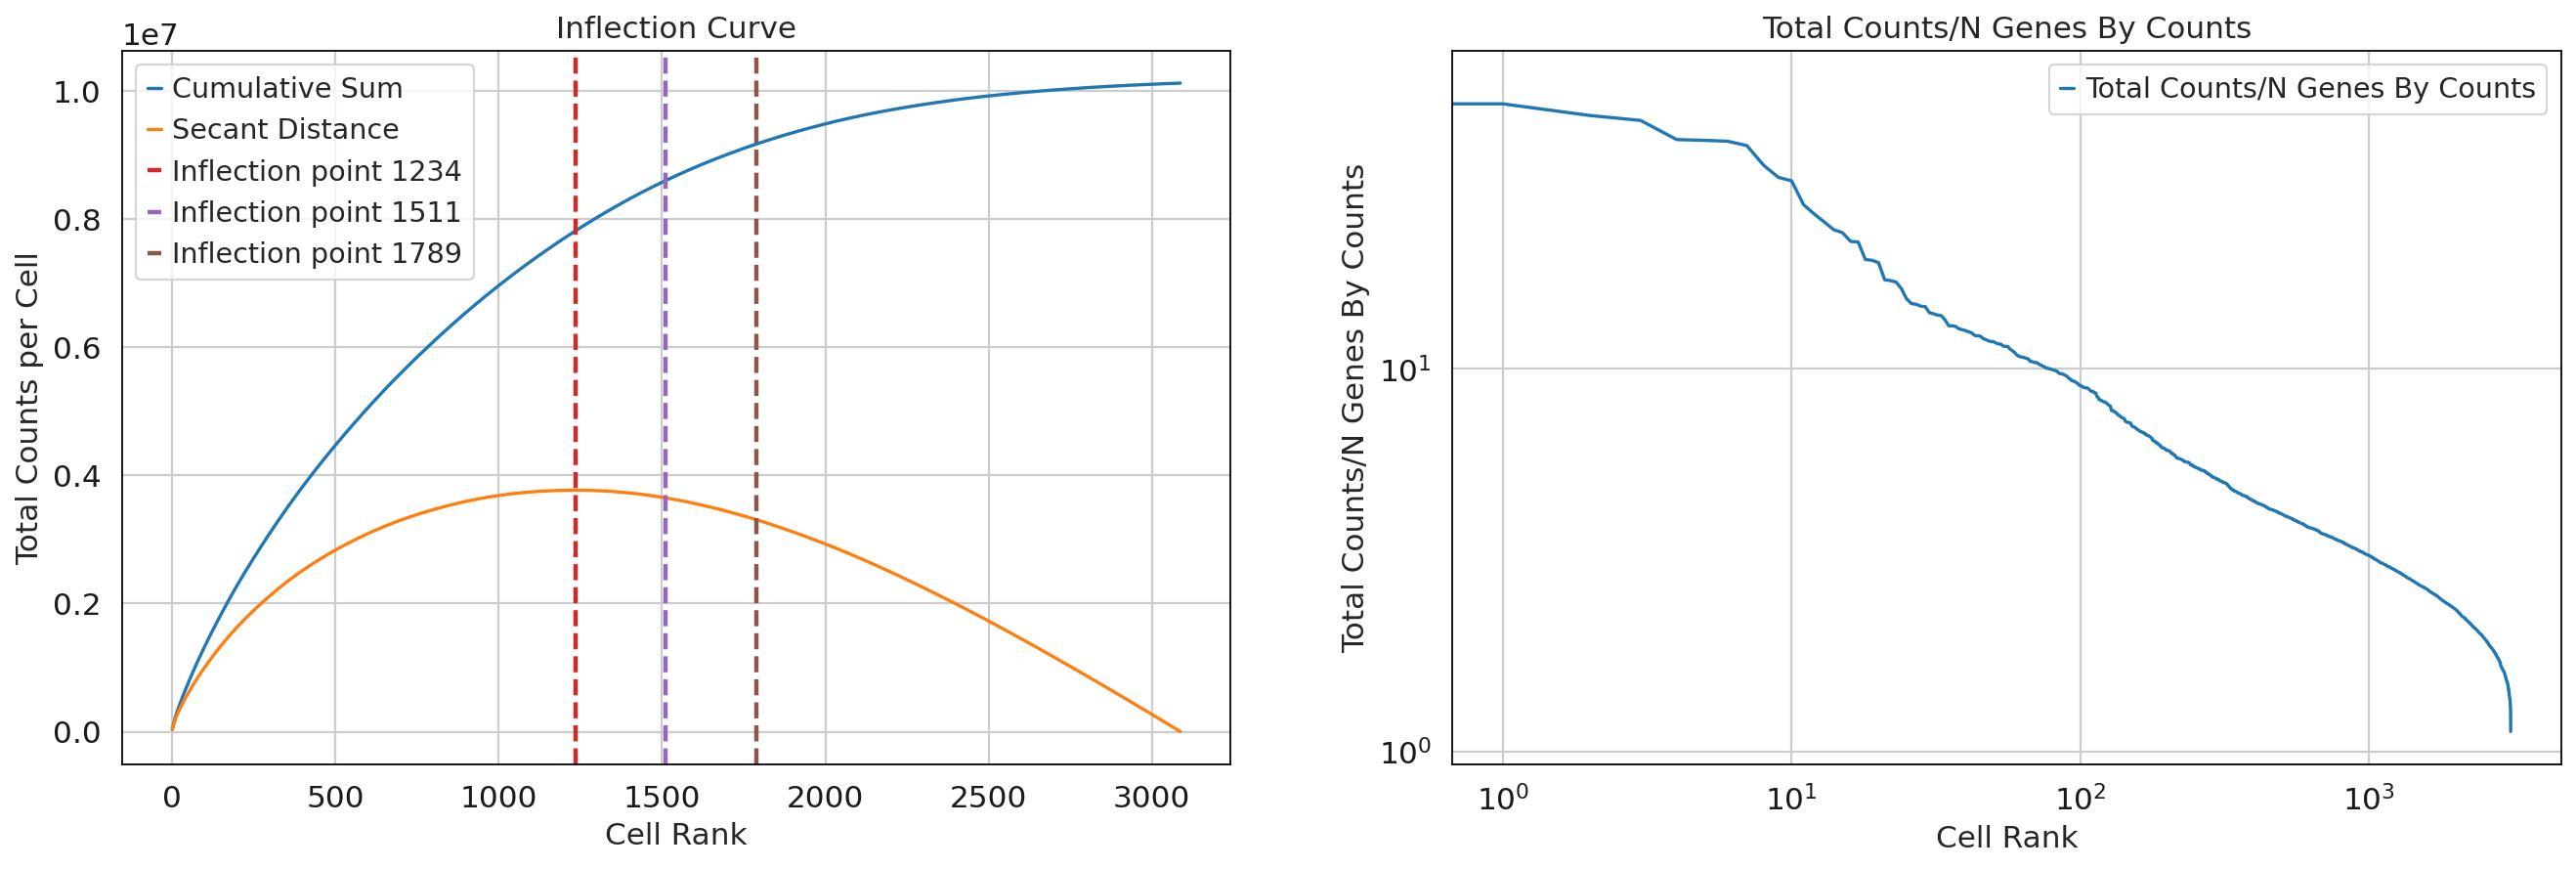

In [19]:
dat_cut = abq.cut_off_h5ad( dat )

In [20]:
dat

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts'

In [21]:
dat_cut

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'Order', 'inflection1', 'inflection_fold'

Top 11 ambient genes have dropout rates between 0.0 and 0.453 percent:
	['MT-ND3', 'MT-CYB', 'MT-ND4', 'MT-CO3', 'MT-RNR2', 'RP5-857K21.4', 'MT-ND2', 'MT-ATP6', 'MT-CO1', 'MT-ND1', 'MT-CO2']
Overall score: -1200039.4795443062


[0.49862778221113624,
 -3769031.782059585,
 -1115583.5459836833,
 0.5018223153738428,
 11,
 47.58553230275215,
 AnnData object with n_obs × n_vars = 3088 × 23621
     obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient', 'ambient_count', 'log_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial'
     var: 'pct_dropout_by_counts', 'ambient', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'total_counts', 'log1p_total_counts', 'Mitochondrial'
     uns: 'num_ambient', 'Order', 'inflection1', 'inflection_fold']

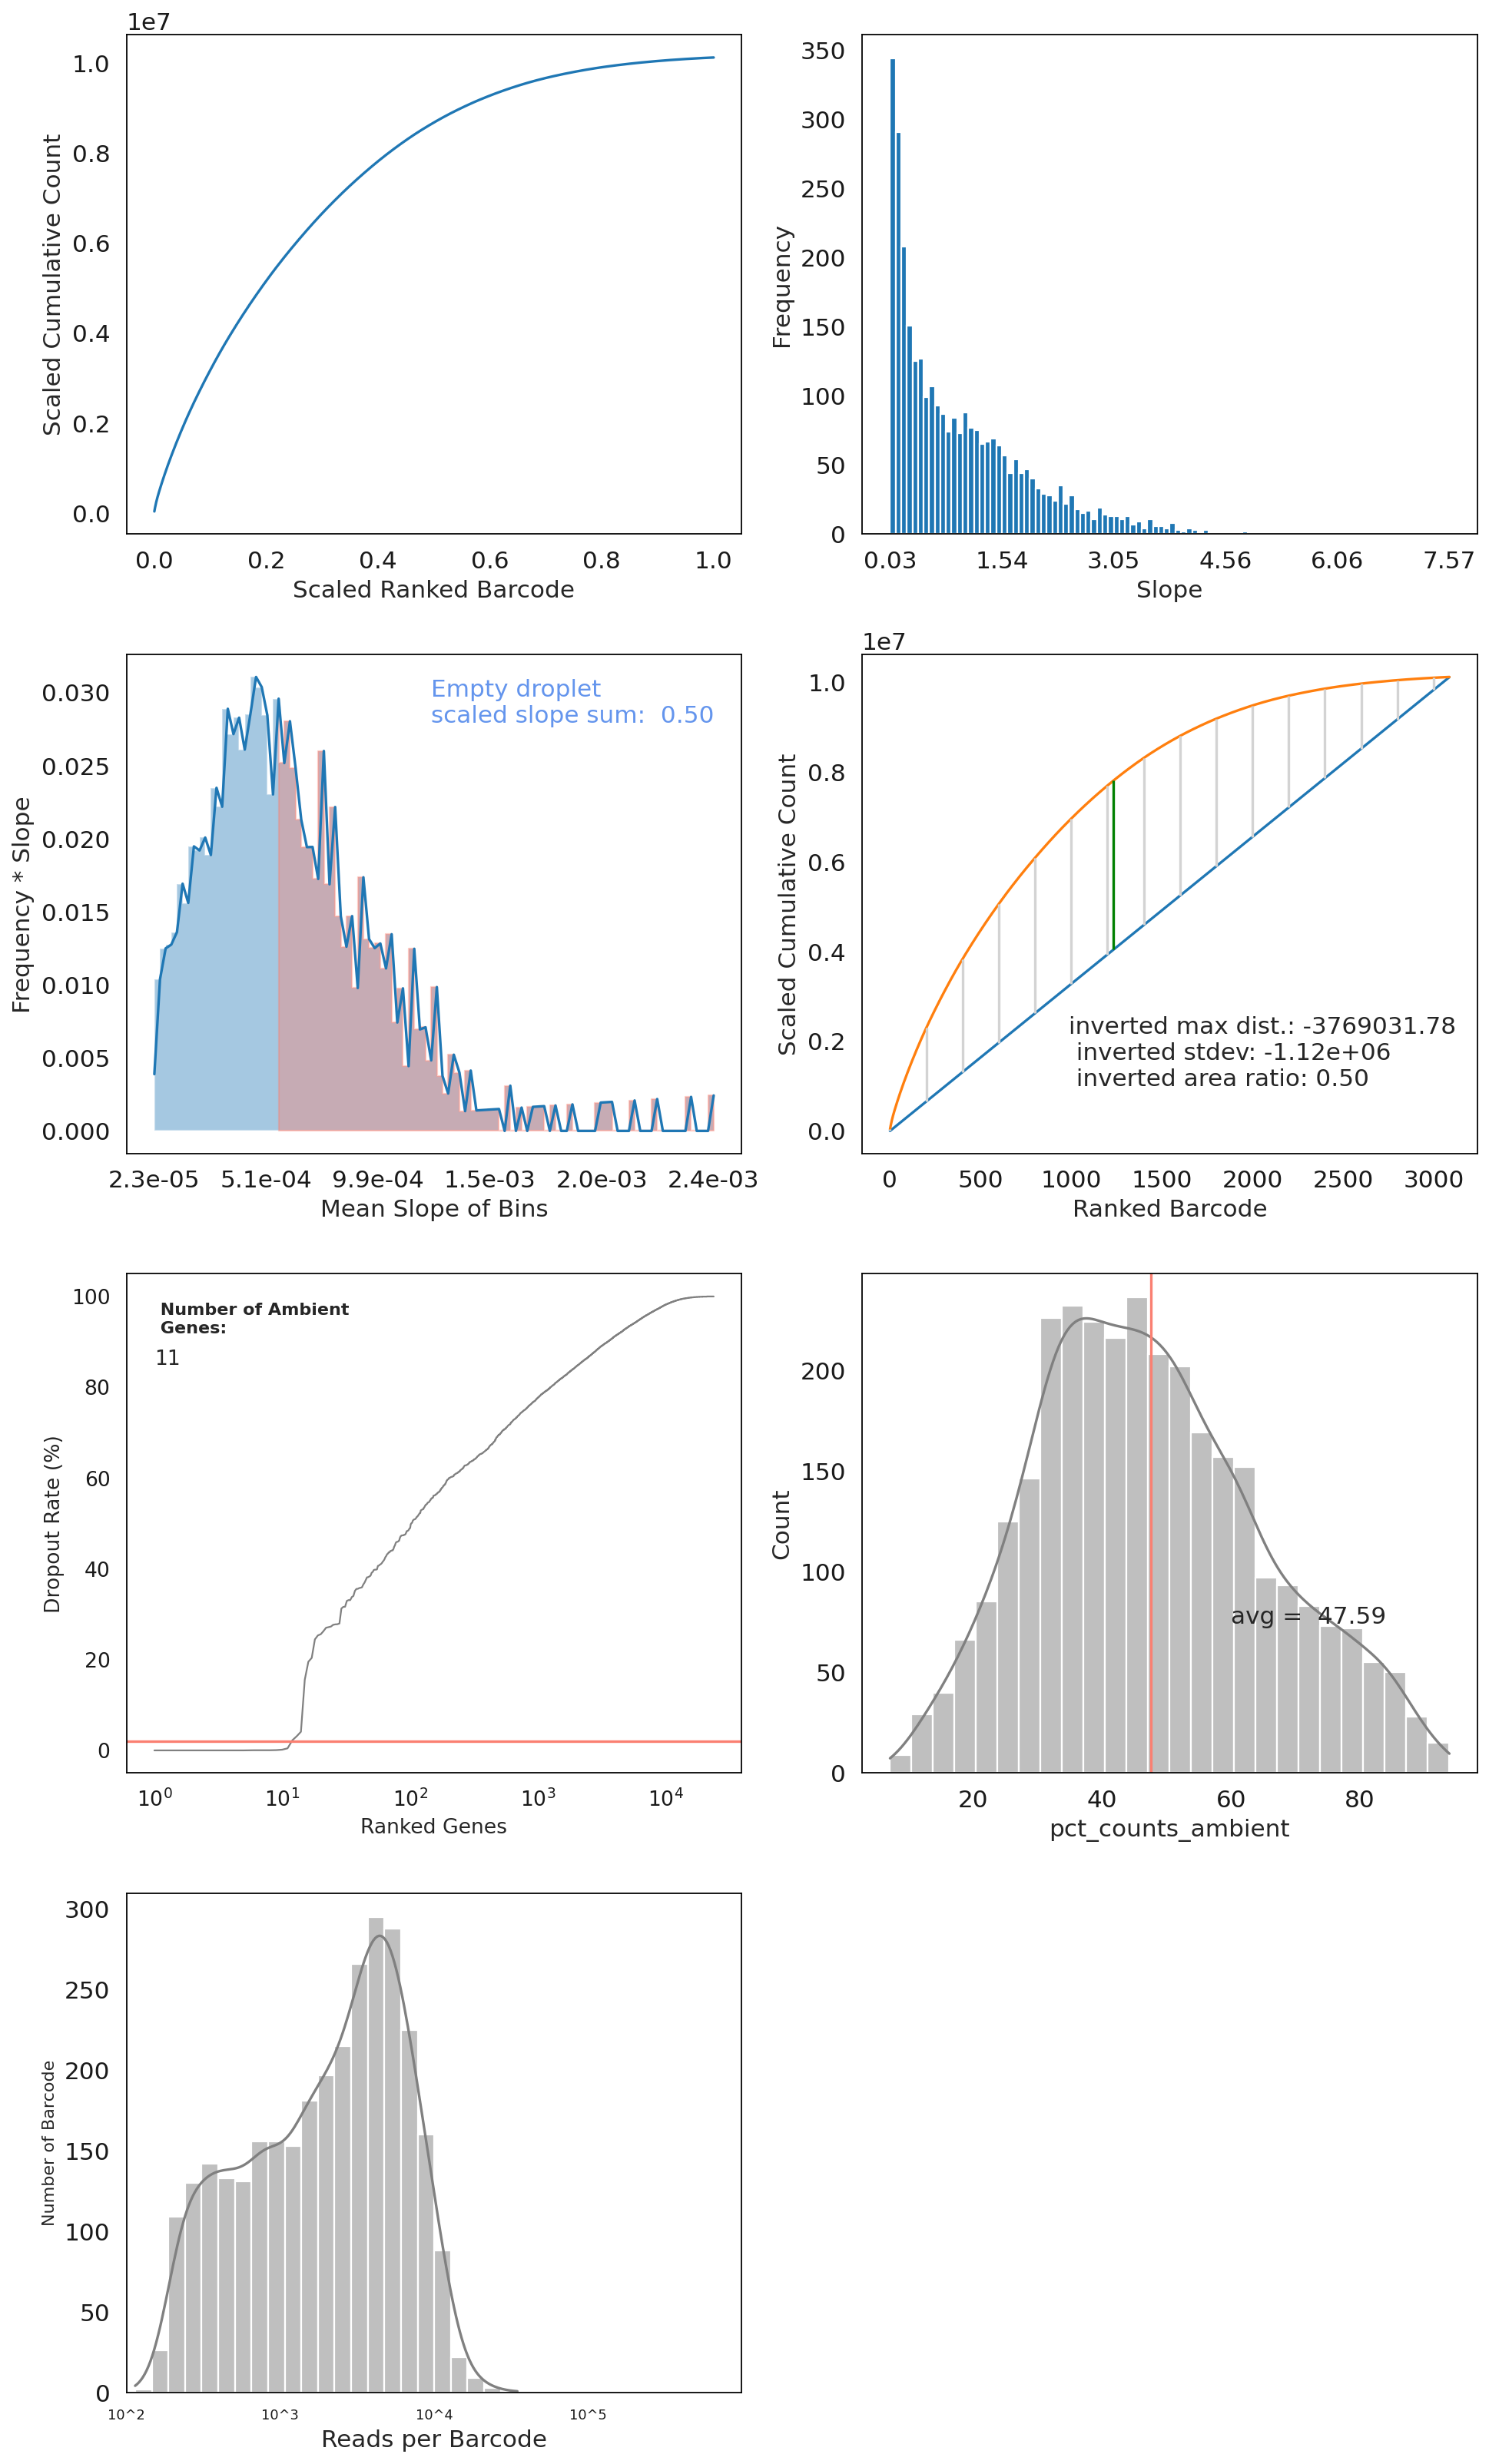

In [42]:
abq.formatted_figures_inverted( dat_cut, ncols = 2  )

In [43]:
amb_ls = ['MT-ND3', 'MT-CYB', 'MT-ND4', 'MT-CO3', 'MT-RNR2', 'RP5-857K21.4', 'MT-ND2', 'MT-ATP6', 'MT-CO1', 'MT-ND1', 'MT-CO2']

In [46]:
dat_cut.X.sum(axis = 1)

array([34803, 24734, 22388, ...,   155,   117,   114])

In [47]:
dat_cut = zc_filter.add_mito_amb_col( dat_cut, mito_str='MT-', amb_ls=amb_ls, run_qc=True)

In [165]:
dat_cut

AnnData object with n_obs × n_vars = 3088 × 23621
    obs: 'total_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_Mitochondrial', 'log1p_total_counts_Mitochondrial', 'pct_counts_Mitochondrial', 'total_counts_ambient', 'log1p_total_counts_ambient', 'pct_counts_ambient'
    var: 'Mitochondrial', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'ambient'
    uns: 'Order', 'inflection1', 'inflection_fold'

In [166]:
dat_cut.X.sum( axis = 1) 

array([34803, 24734, 22388, ...,   155,   117,   114])

In [167]:
dat_cut.write("./s78_post_ambiQuant_dat.h5ad", compression = 'gzip')